In [1]:
import numpy as np

docs = [
    'go india',
    'india india',
    'hip hip hurray',
    'jeetega bhai jeetega india jeetega',
    'bharat mata ki jai',
    'kohli kohli',
    'sachin sachin',
    'dhoni dhoni',
    'modi ji ki jai',
    'inquilab zindabad'
]

In [2]:
import tensorflow
from tensorflow.keras.preprocessing.text import Tokenizer

In [3]:
tokenizer=Tokenizer(oov_token='<nothing>')

In [4]:
# Word converted to indexs
tokenizer.fit_on_texts(docs)

In [5]:
tokenizer.word_index

{'<nothing>': 1,
 'india': 2,
 'jeetega': 3,
 'hip': 4,
 'ki': 5,
 'jai': 6,
 'kohli': 7,
 'sachin': 8,
 'dhoni': 9,
 'go': 10,
 'hurray': 11,
 'bhai': 12,
 'bharat': 13,
 'mata': 14,
 'modi': 15,
 'ji': 16,
 'inquilab': 17,
 'zindabad': 18}

In [6]:
tokenizer.word_counts

OrderedDict([('go', 1),
             ('india', 4),
             ('hip', 2),
             ('hurray', 1),
             ('jeetega', 3),
             ('bhai', 1),
             ('bharat', 1),
             ('mata', 1),
             ('ki', 2),
             ('jai', 2),
             ('kohli', 2),
             ('sachin', 2),
             ('dhoni', 2),
             ('modi', 1),
             ('ji', 1),
             ('inquilab', 1),
             ('zindabad', 1)])

In [7]:
tokenizer.document_count

10

In [8]:
# Sentence written as a sequence of indexs
sequence= tokenizer.texts_to_sequences(docs)
sequence

[[10, 2],
 [2, 2],
 [4, 4, 11],
 [3, 12, 3, 2, 3],
 [13, 14, 5, 6],
 [7, 7],
 [8, 8],
 [9, 9],
 [15, 16, 5, 6],
 [17, 18]]

In [9]:
from keras.utils import pad_sequences

In [10]:
# Zero padding on sequences
sequence=pad_sequences(sequence, padding='post')

In [11]:
sequence

array([[10,  2,  0,  0,  0],
       [ 2,  2,  0,  0,  0],
       [ 4,  4, 11,  0,  0],
       [ 3, 12,  3,  2,  3],
       [13, 14,  5,  6,  0],
       [ 7,  7,  0,  0,  0],
       [ 8,  8,  0,  0,  0],
       [ 9,  9,  0,  0,  0],
       [15, 16,  5,  6,  0],
       [17, 18,  0,  0,  0]])

# Directly importing IMDB data from keras and applying sentiment analysis

In [12]:
from keras.datasets import imdb
from keras.layers import Dense, Flatten, SimpleRNN, Embedding
from keras.models import Sequential

In [13]:
model=Sequential()

In [31]:
(X_train, y_train), (X_test, y_test)=imdb.load_data()

In [15]:
X_train.shape, X_test.shape

((25000,), (25000,))

In [16]:
y_train.shape, y_test.shape

((25000,), (25000,))

In [32]:
X_train=pad_sequences(X_train, padding='post')
X_test=pad_sequences(X_test, padding='post')

In [18]:
# We have also trimmed the vector len to 50 as to reduce the model complexity
X_train[0].shape

(50,)

In [33]:
model=Sequential()

model.add(SimpleRNN(32, input_shape=(50, 1), return_sequences=False, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from keras.utils import plot_model
plot_model(model, show_shapes=True)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [34]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'] )

In [35]:
history=model.fit(X_train, y_train,epochs=10, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 259s 413ms/step - accuracy: 0.4972 - loss: 0.6942 - val_accuracy: 0.4938 - val_loss: 0.6936
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 292s 467ms/step - accuracy: 0.5009 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 244s 390ms/step - accuracy: 0.4954 - loss: 0.6931 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 119s 190ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.4938 - val_loss: 0.6933
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 201ms/step - accuracy: 0.5016 - loss: 0.6931 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 142s 228ms/step - accuracy: 0.4960 - loss: 0.6931 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 137s 219ms/step - accuracy: 0.4940 - loss: 0.6931 - val_accuracy: 0.4938 - val_loss: 0.6932
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 127s 203ms/step - accuracy: 0.5016 -

In [23]:
import matplotlib.pyplot as plt

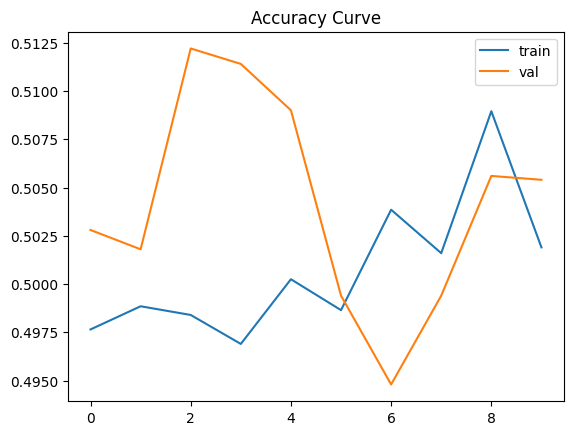

In [24]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

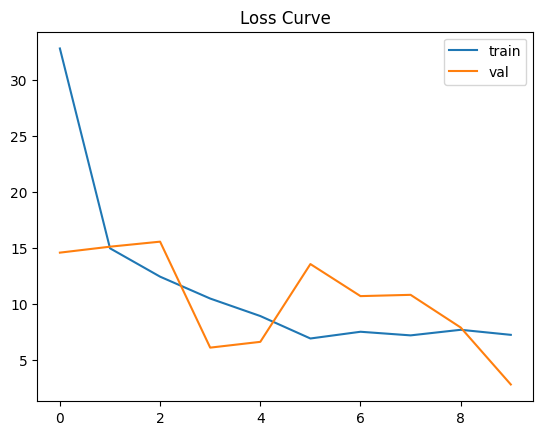

In [25]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [26]:
y_pred=model.predict(X_train)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [27]:
y_pred = np.where(y_pred > 0.5, 0, 1)

In [28]:
y_pred

array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [0]])

In [29]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

In [30]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("Precission: ", precision_score(y_test, y_pred))

Accuracy:  0.49896
Recall:  0.59624
Precission:  0.49912938655237077
